In [1]:
import pandas as pd
import numpy as np
# from charset_normalizer import md__mypyc
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.layers import LSTM,Bidirectional,GRU
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
import datetime
import io
import itertools
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV

#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
#from scikeras.wrappers import KerasClassifier
import sys
import os
os.chdir('..')

current_dir = os.getcwd()
print(current_dir)

# Construir la ruta relativa al directorio que quieres agregar
relative_dir = os.path.join(current_dir, 'mis_pkgs/')

# Agregar la ruta relativa al sys.path
sys.path.insert(0, relative_dir)

import optuna
from optuna.integration import TFKerasPruningCallback
from optuna.trial import TrialState

numero_muestras=201
numero_clases=2
entrada=slice(9,11)
numero_entradas = entrada.stop - entrada.start
numero_epochs=1000

filename = "COPIA_PANDAS/medidas_agilent_2023_y_2024_201_puntos_clasificados.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    # p_e =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_train=np.zeros((pre_p_e1.shape[0],numero_muestras,numero_entradas))
    y_train=np.zeros((pre_p_e1.shape[0],1))
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if numero_clases==2:
            if estado == 0 or estado== 1:
                target = 0
            else:
                target = 1
        else:
            target=estado
        pepito=np.array(t.iloc[Primero:Ultimo+1])
        # #print(pepito.shape)
        X_train[x]=pepito[:,entrada]
        #X_train[x]=X_train[x].reshape(X_train[x].shape[0],-1)
        #print(X_train[x][0:4,:])       
        y_train[x]=target
        y_train_to_categorical = to_categorical(y_train)
        x=x+1


# print(X_train.shape)
# print(y_train_to_categorical.shape)
# #print(X_train[0:4,:,:])
# #print(X_train[1][0:4][:])
# print(y_train[1:20])
# print(y_train_to_categorical[1:20])
# # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# print(p_e)
# # X_train_filtrado = X_train[2:][:,:]
# # y_train_filtrado = y_train[2:]
X_train_filtrado = X_train
#y_train_filtrado = y_train
y_train_filtrado = y_train_to_categorical

# print(X_train_filtrado.shape)
# print(y_train_filtrado.shape)
# print(X_train_filtrado[0][:,:])
# # # Vamos a normalizar o escalar los datos
scaler = StandardScaler()
data_2d = X_train_filtrado.reshape(-1, X_train_filtrado.shape[-1])
normalized_data_2d = scaler.fit_transform(data_2d)
#para recurrentes
#X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape) #para recurrentes
#para densas
X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape)
y_train_Normalizado=y_train_filtrado # los valores ya estaban normalizados
print(X_train_Normalizado.shape)
print(y_train_Normalizado.shape)



2024-07-10 14:19:03.123523: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-10 14:19:03.123593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-10 14:19:03.125106: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-10 14:19:03.132537: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-10 14:19:03.924007: W tensorflow/compiler/tf2

/home/rgadea/nuevas_investigaciones_alimentos_2024


/home/rgadea/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(194, 201, 2)
(194, 2)


In [3]:


X_train_def, X_test_def, y_train_def, y_test_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.2, random_state=42)

factor_aprendizaje=0.001
dimension_LSTM=200
dimension_dense1=50
dimension_dense2=20
algoritmo='rmsprop'
supermax=8*4
lossfunction='categorical_crossentropy'

INPUT_SHAPE=(X_train_def.shape[1],)                                                      

TRIALS = 35


# utility function to create model trials
def create_model(trial):
    nodes1 = trial.suggest_int("n_nodes1", 50, 400)
    model = Sequential()
    model.add(Bidirectional(GRU(nodes1, return_sequences=True, recurrent_regularizer='L2'),input_shape=(numero_muestras, numero_entradas)))
    model.add(Flatten())  
    # # model.add(GRU(50, return_sequences=True))
    # model.add(GRU(50, return_sequences=False))
    model.add(Dense(dimension_dense1, activation='tanh', activity_regularizer='L2'))
    model.add(Dense(dimension_dense2, activation='tanh'))
    model.add(Dense(numero_clases, activation='softmax'))
    model.compile(loss=lossfunction, optimizer=algoritmo, metrics=['accuracy',
                              tf.keras.metrics.Recall(class_id=0),
                              tf.keras.metrics.Recall(class_id=1) #,                                                                   
                                                                   ])
   # model.optimizer.lr=(factor_aprendizaje)
    return model
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=False)
    
# Objective function
def objective(trial):
    
    # instantiate model
    model_opt = create_model(trial)
    
    # fit the model
    model_opt.fit(X_train_def,y_train_def
                  ,epochs = numero_epochs
                  ,batch_size=20
                  ,shuffle=True

                  ,validation_data=(X_test_def, y_test_def)
                  ,verbose=0
                  ,callbacks=[early_stop,lr_callback]
                  )
    
    # calculate accuracy score
    acc_score = model_opt.evaluate(X_test_def, y_test_def, verbose=0)[1]
    
    return acc_score


# perform the optimization
study = optuna.create_study(
    direction="maximize", 
    #sampler=optuna.samplers.TPESampler(), 
    #pruner=optuna.pruners.HyperbandPruner(),   
    storage="sqlite:///db.sqlite3")  # Specify the storage URL here.study_name="baseline model optimization"
study.optimize(objective, n_trials=TRIALS, n_jobs=-1)


# print out 
print('*'*100)
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("Best Params:")
print(study.best_params)
print('*'*100)


[I 2024-07-10 14:20:47,231] A new study created in RDB with name: no-name-076edc58-7777-44b7-9379-dfbb577cf715


[W 2024-07-10 14:20:50,748] Trial 0 failed with parameters: {'n_nodes1': 183} because of the following error: NameError("name 'Flatten' is not defined").
Traceback (most recent call last):
  File "/home/rgadea/.local/lib/python3.10/site-packages/optuna/study/_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_124038/1073395277.py", line 45, in objective
    model_opt = create_model(trial)
  File "/tmp/ipykernel_124038/1073395277.py", line 21, in create_model
    model.add(Flatten())
NameError: name 'Flatten' is not defined
[W 2024-07-10 14:20:50,750] Trial 1 failed with parameters: {'n_nodes1': 269} because of the following error: NameError("name 'Flatten' is not defined").
Traceback (most recent call last):
  File "/home/rgadea/.local/lib/python3.10/site-packages/optuna/study/_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_124038/1073395277.py", line 45, in objective
    model_opt = create_mode

NameError: name 'Flatten' is not defined

In [ ]:

# get the optimized model
baseline_model_opt = create_model(study.best_trial)
baseline_model_opt.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 91)             │       292,019 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         2,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,465 (1.12 MB)

 Trainable params: 294,465 (1.12 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5143 - loss: 68.4101 - val_accuracy: 0.5616 - val_loss: 50.7876
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5285 - loss: 56.9926 - val_accuracy: 0.6073 - val_loss: 41.9542
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5567 - loss: 47.9892 - val_accuracy: 0.4772 - val_loss: 35.2107
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5340 - loss: 42.3928 - val_accuracy: 0.5594 - val_loss: 31.8203
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5559 - loss: 39.4678 - val_accuracy: 0.5388 - val_loss: 32.9599
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5336 - loss: 39.4323 - val_accuracy: 0.5662 - val_loss: 35.7845
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5750 - loss: 39.8245 - val_accuracy: 0.6279 - val_loss: 33.0087
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5916 - loss: 39.7618 -

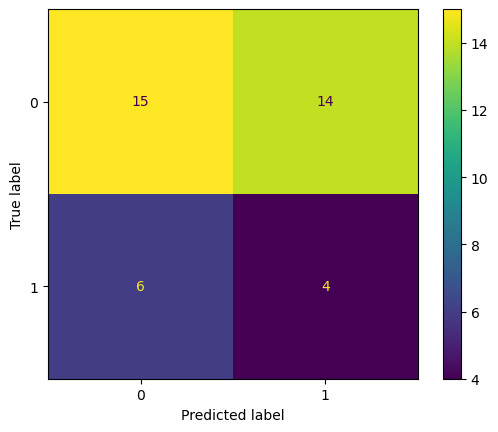

              precision    recall  f1-score   support

      Buenos     0.7143    0.5172    0.6000        29
       Malos     0.2222    0.4000    0.2857        10

    accuracy                         0.4872        39
   macro avg     0.4683    0.4586    0.4429        39
weighted avg     0.5881    0.4872    0.5194        39



AttributeError: 'Study' object has no attribute 'n_nodes2'

In [ ]:

# clear session
tf.keras.backend.clear_session()
early_stop2=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
    

baseline_model_opt.fit(X_train_def, y_train_def, epochs=numero_epochs, batch_size=100, callbacks=[early_stop2], validation_data=(X_val_def, y_val_def))
# Final evaluation of the model 
scores = baseline_model_opt.evaluate(X_test_def, y_test_def, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

y_pred = baseline_model_opt.predict(X_test_def)
#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
#y_pred2=np.where(y_pred>0,1,0)
#y_pred2=y_pred2[:,-1]
y_test_def2=np.argmax(y_test_def,axis=1)
#y_test_def2=np.where(y_test_def>0,1,0)
print(y_pred.shape)
print(y_pred2.shape)
print(y_test_def2.shape)
#print(y_test_def[25])
print(y_pred2)

#docs_infra: no_execute
if numero_clases==2:
    classes = [0, 1]
else:   
    classes = [0, 1, 2, 3, 4]
#classes = [0, 1]
cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

from sklearn.metrics import classification_report
if numero_clases==2:
    target_names = ['Buenos', 'Malos']
else:   
    target_names = ['A', 'B+', 'B', 'B-','C']
print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))

#model.save('idea.h5')  # creates a HDF5 file 'my_model.h5'


# Generar una lista de los números en el rango del slice
numbers = list(range(entrada.start, entrada.stop))

# Convertir la lista a un string con los números separados por guiones
slice_str = "-".join(map(str, numbers))
# Obtén los mejores parámetros
best_params = study.best_trial.params


In [ ]:

n_nodes1 = best_params["n_nodes1"]
n_nodes2 = best_params["n_nodes2"]
experimento="LOMOS_Agilent_entradas_{}_dense1_{}_dense2_{}_clases_{}_loss_{}_lr_{}_algoritmo_{}".format(slice_str,n_nodes1,n_nodes2,numero_clases,lossfunction,factor_aprendizaje,algoritmo)
baseline_model_opt.save('modelos\modelo_optimo_{}_{}.h5'.format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))) 

In [ ]:
print(slice_str)

3-4-5-6-7-8-9-10
